In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [119]:
df = pd.read_csv("../artifacts/raw/data.csv")

In [120]:
df.head()

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


In [121]:
df.shape

(100000, 13)

In [122]:
df['Operation_Mode'].value_counts()

Operation_Mode
Active         70054
Idle           20057
Maintenance     9889
Name: count, dtype: int64

In [123]:
df['Efficiency_Status'].value_counts()

Efficiency_Status
Low       77825
Medium    19189
High       2986
Name: count, dtype: int64

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Timestamp                      100000 non-null  str    
 1   Machine_ID                     100000 non-null  int64  
 2   Operation_Mode                 100000 non-null  str    
 3   Temperature_C                  100000 non-null  float64
 4   Vibration_Hz                   100000 non-null  float64
 5   Power_Consumption_kW           100000 non-null  float64
 6   Network_Latency_ms             100000 non-null  float64
 7   Packet_Loss_%                  100000 non-null  float64
 8   Quality_Control_Defect_Rate_%  100000 non-null  float64
 9   Production_Speed_units_per_hr  100000 non-null  float64
 10  Predictive_Maintenance_Score   100000 non-null  float64
 11  Error_Rate_%                   100000 non-null  float64
 12  Efficiency_Status              100000 non-

## Data Processing

In [125]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'],errors="coerce")

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Timestamp                      100000 non-null  datetime64[us]
 1   Machine_ID                     100000 non-null  int64         
 2   Operation_Mode                 100000 non-null  str           
 3   Temperature_C                  100000 non-null  float64       
 4   Vibration_Hz                   100000 non-null  float64       
 5   Power_Consumption_kW           100000 non-null  float64       
 6   Network_Latency_ms             100000 non-null  float64       
 7   Packet_Loss_%                  100000 non-null  float64       
 8   Quality_Control_Defect_Rate_%  100000 non-null  float64       
 9   Production_Speed_units_per_hr  100000 non-null  float64       
 10  Predictive_Maintenance_Score   100000 non-null  float64       
 11  Error_Rate_%

In [127]:
df.isnull().sum()

Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

In [128]:
df.duplicated().sum()

np.int64(0)

In [129]:
categorical_cols = ['Operation_Mode','Efficiency_Status']
for col in categorical_cols:
    df[col] = df[col].astype(dtype="category")

In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Timestamp                      100000 non-null  datetime64[us]
 1   Machine_ID                     100000 non-null  int64         
 2   Operation_Mode                 100000 non-null  category      
 3   Temperature_C                  100000 non-null  float64       
 4   Vibration_Hz                   100000 non-null  float64       
 5   Power_Consumption_kW           100000 non-null  float64       
 6   Network_Latency_ms             100000 non-null  float64       
 7   Packet_Loss_%                  100000 non-null  float64       
 8   Quality_Control_Defect_Rate_%  100000 non-null  float64       
 9   Production_Speed_units_per_hr  100000 non-null  float64       
 10  Predictive_Maintenance_Score   100000 non-null  float64       
 11  Error_Rate_%

## EDA

In [131]:
numerical_cols = df.select_dtypes(include=[np.number]).columns

In [132]:
numerical_cols

Index(['Machine_ID', 'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
       'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
       'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score',
       'Error_Rate_%'],
      dtype='str')

In [133]:
len(numerical_cols)

10

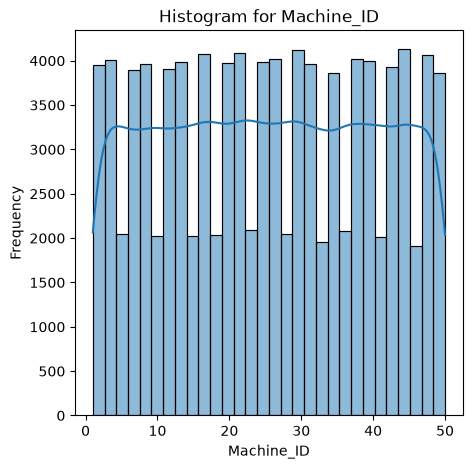

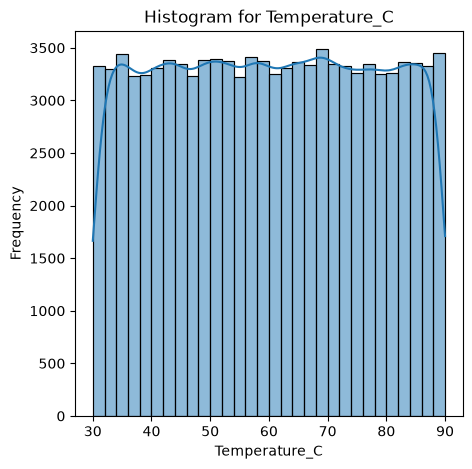

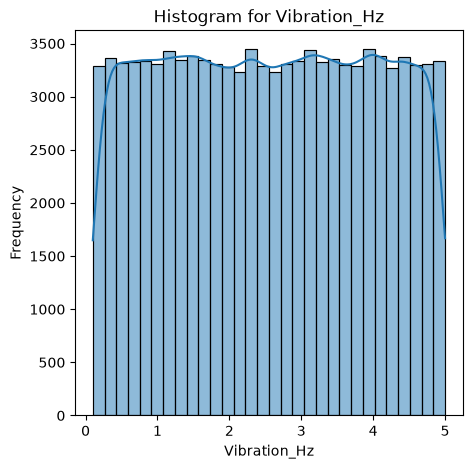

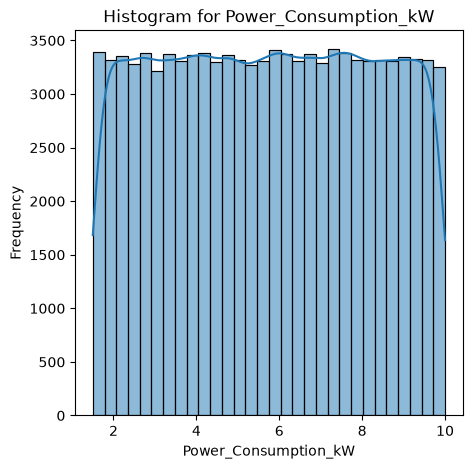

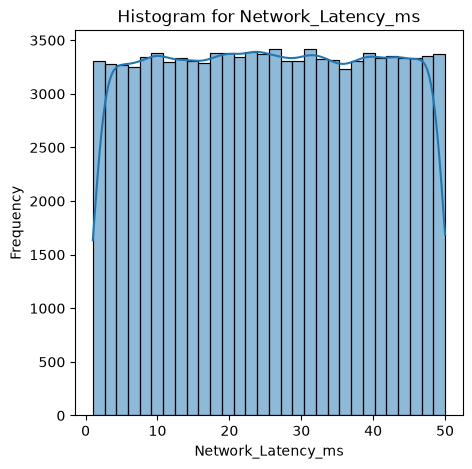

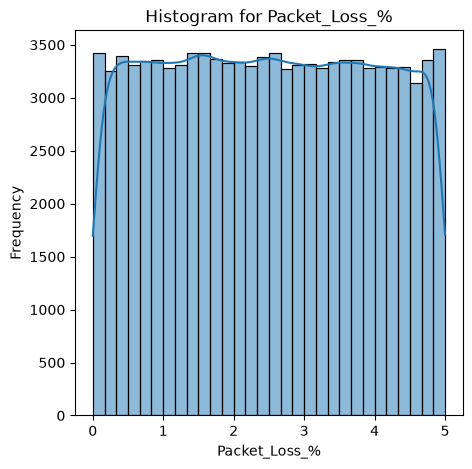

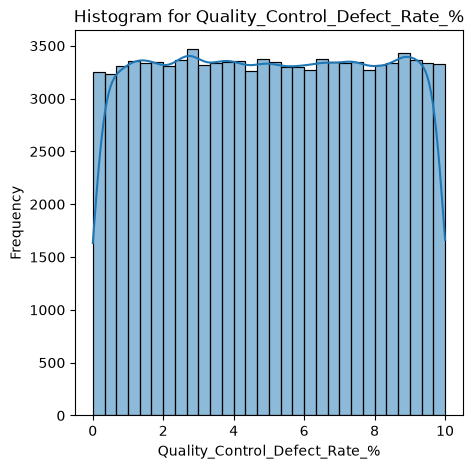

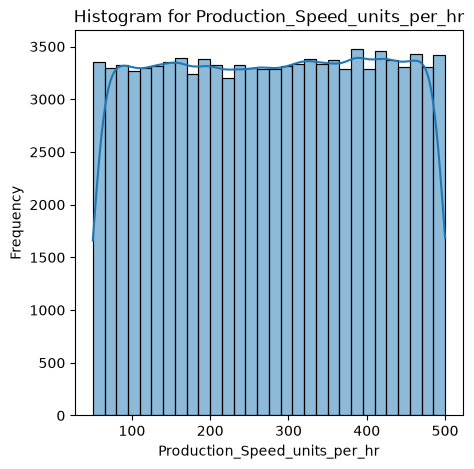

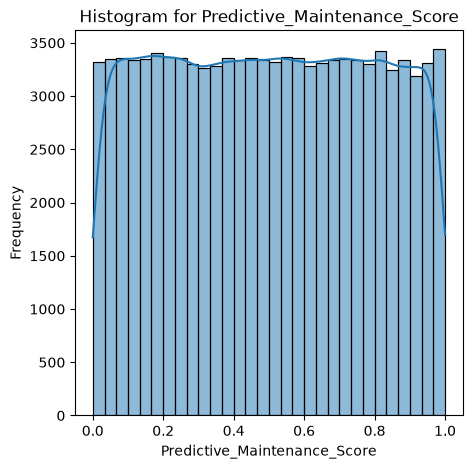

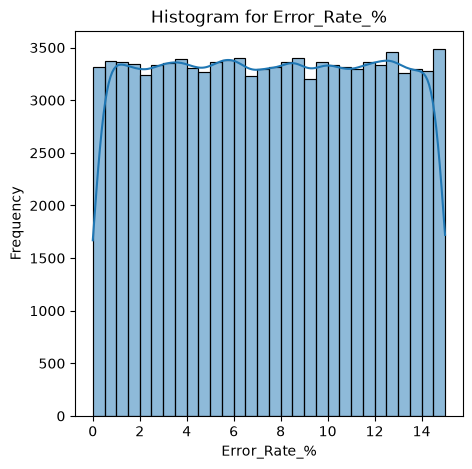

In [134]:
for col in numerical_cols:
    plt.figure(figsize=(5,5))
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(f"Histogram for {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

<Axes: xlabel='Efficiency_Status', ylabel='count'>

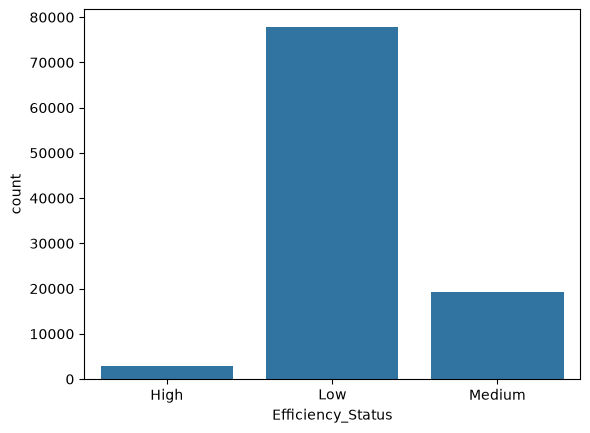

In [135]:
sns.barplot(df['Efficiency_Status'].value_counts())

In [136]:
df['Efficiency_Status'].value_counts()

Efficiency_Status
Low       77825
Medium    19189
High       2986
Name: count, dtype: int64

## Feature Engineering

In [137]:
df.head(2)

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.96547,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.67827,Low


In [138]:
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour

In [139]:
df.sample(5)

,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status,Year,Month,Day,Hour
82279,2024-02-27 03:19:00,39,Active,40.174044,4.683704,2.181358,36.112196,3.329948,4.708555,431.386581,0.425720,4.102948,Medium,2024,2,27,3
69249,2024-02-18 02:09:00,11,Active,61.894024,4.137082,7.177854,39.394612,1.733163,6.409334,276.233336,0.525074,0.795161,Medium,2024,2,18,2
13273,2024-01-10 05:13:00,24,Active,49.573695,0.210490,4.089833,1.994327,1.526190,8.789908,129.908259,0.515551,7.950743,Low,2024,1,10,5
48095,2024-02-03 09:35:00,34,Maintenance,45.314304,0.687250,6.722341,10.859689,2.879892,6.884736,100.689968,0.453861,10.846530,Low,2024,2,3,9
48203,2024-02-03 11:23:00,34,Maintenance,41.031083,4.726670,1.753404,23.342611,4.922695,9.614213,101.946465,0.288702,12.828282,Low,2024,2,3,11


In [140]:
df.drop(columns=['Timestamp','Machine_ID'],inplace=True)

In [141]:
df.head(1)

,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status,Year,Month,Day,Hour
0,Idle,74.13759,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.34465,14.96547,Low,2024,1,1,0


In [142]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [143]:
df['Efficiency_Target'] = label_encoder.fit_transform(df['Efficiency_Status'])

In [144]:
print(df['Efficiency_Status'].value_counts(),df['Efficiency_Target'].value_counts())

Efficiency_Status
Low       77825
Medium    19189
High       2986
Name: count, dtype: int64 Efficiency_Target
1    77825
2    19189
0     2986
Name: count, dtype: int64


In [145]:
label_encoder = LabelEncoder()

In [146]:
df['Operation_Mode_Labels'] = label_encoder.fit_transform(df['Operation_Mode'])

In [147]:
print(df['Operation_Mode'].value_counts(),df['Operation_Mode_Labels'].value_counts())

Operation_Mode
Active         70054
Idle           20057
Maintenance     9889
Name: count, dtype: int64 Operation_Mode_Labels
0    70054
1    20057
2     9889
Name: count, dtype: int64


In [148]:
df.columns

Index(['Operation_Mode', 'Temperature_C', 'Vibration_Hz',
       'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%',
       'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
       'Predictive_Maintenance_Score', 'Error_Rate_%', 'Efficiency_Status',
       'Year', 'Month', 'Day', 'Hour', 'Efficiency_Target',
       'Operation_Mode_Labels'],
      dtype='str')

In [149]:
features=['Operation_Mode_Labels', 'Temperature_C', 'Vibration_Hz',
       'Power_Consumption_kW', 'Network_Latency_ms', 'Packet_Loss_%',
       'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
       'Predictive_Maintenance_Score', 'Error_Rate_%','Year', 'Month', 'Day', 'Hour'
]

In [150]:
X = df[features]
y = df['Efficiency_Target']

In [151]:
X

,Operation_Mode_Labels,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Year,Month,Day,Hour
0,1,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,2024,1,1,0
1,0,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,2024,1,1,0
2,0,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,2024,1,1,0
3,0,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,2024,1,1,0
4,1,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,2024,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,71.143556,1.861171,2.897206,11.967279,4.670305,2.823803,282.822791,0.133871,12.631304,2024,3,10,10
99996,1,77.256970,0.377495,5.037060,39.687650,3.996942,6.065958,466.696532,0.775575,2.292894,2024,3,10,10
99997,0,52.800333,2.629977,3.900503,26.721615,4.821022,5.090971,324.277200,0.151740,6.315872,2024,3,10,10
99998,0,79.967251,2.283934,7.156484,9.534678,0.481175,8.333964,65.965864,0.989501,4.802397,2024,3,10,10


In [152]:
y

0        1
1        1
2        1
3        2
4        1
        ..
99995    1
99996    2
99997    1
99998    1
99999    1
Name: Efficiency_Target, Length: 100000, dtype: int64

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [154]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [155]:
X_test

,Operation_Mode_Labels,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Year,Month,Day,Hour
48737,0,32.502298,0.445714,8.858478,39.545757,4.724805,1.334047,76.518590,0.007504,0.749172,2024,2,3,20
94298,0,74.877606,4.571889,6.349452,19.679387,2.328610,6.879984,332.056310,0.909713,5.443722,2024,3,6,11
43627,1,38.185581,2.380478,9.519807,5.786158,3.931080,2.911974,114.953094,0.692201,3.288747,2024,1,31,7
59532,0,35.251011,3.069692,3.190789,39.129078,2.854463,9.263633,218.372947,0.085651,5.805677,2024,2,11,8
85327,0,89.205249,1.122762,6.161044,22.042357,4.410473,0.787613,355.083859,0.208036,8.189646,2024,2,29,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97322,0,32.664329,0.414379,8.317466,47.253532,2.196359,6.064304,202.572462,0.583103,0.405087,2024,3,8,14
44599,2,75.121009,2.676869,5.827555,1.284473,2.290067,8.881706,355.853833,0.613201,10.493452,2024,1,31,23
92043,0,70.271368,1.571491,4.055913,6.167544,1.955657,2.506259,244.975381,0.828993,10.343966,2024,3,4,22
63527,0,37.297161,2.939641,4.263950,36.401692,2.897485,4.559023,119.099942,0.184210,14.890823,2024,2,14,2


In [156]:
x_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    

In [157]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

In [158]:
X_train_resampled,y_train_resampled = smote.fit_resample(x_train_scaled,y_train)

In [159]:
X_train_resampled

array([[-0.60124444, -0.23411946,  1.1254019 , ..., -0.99191396,
         0.43725648,  0.9445137 ],
       [ 2.4265508 ,  0.85845758,  0.60235174, ...,  0.44255009,
        -0.12608044,  0.9445137 ],
       [-0.60124444, -0.87822066, -1.22460937, ...,  0.44255009,
        -0.80208474, -0.50003921],
       ...,
       [-0.60124444,  0.46142335,  1.2054697 , ...,  0.44255009,
        -0.25292089, -1.22231567],
       [ 2.4265508 ,  1.00652367, -1.23490204, ...,  0.44255009,
         1.22974493,  0.51114783],
       [-0.60124444,  1.5264852 ,  0.23456627, ..., -0.99191396,
         0.51413973,  0.18937889]], shape=(186780, 14))

In [160]:
from sklearn.linear_model import LogisticRegression

In [161]:
logistic_regression = LogisticRegression(random_state=42,max_iter=100)

In [162]:
logistic_regression.fit(X_train_resampled,y_train_resampled)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [163]:
y_pred = logistic_regression.predict(X_test_scaled)

In [164]:
from sklearn.metrics import accuracy_score,classification_report

In [165]:
y_test

48737    1
94298    1
43627    1
59532    1
85327    1
        ..
97322    2
44599    1
92043    1
63527    1
61092    1
Name: Efficiency_Target, Length: 20000, dtype: int64

In [166]:
accuracy = accuracy_score(y_test,y_pred)


In [167]:
print("Accuracy",accuracy)

Accuracy 0.8911


In [168]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.69      0.95      0.80       597
           1       0.98      0.90      0.94     15565
           2       0.67      0.84      0.75      3838

    accuracy                           0.89     20000
   macro avg       0.78      0.90      0.83     20000
weighted avg       0.91      0.89      0.90     20000



In [169]:
from sklearn.inspection import permutation_importance

In [170]:
result = permutation_importance(logistic_regression,X_test_scaled,y_test, n_repeats=10,random_state=42, n_jobs=-1)

In [171]:
print(result)

{'importances_mean': array([-1.55000e-04,  9.00000e-05,  1.25000e-04, -9.00000e-05,
       -2.50000e-05,  1.70000e-04,  2.45000e-04,  1.03450e-01,
        0.00000e+00,  2.53035e-01,  0.00000e+00,  7.00000e-05,
        1.10000e-04,  2.40000e-04]), 'importances_std': array([7.56637298e-05, 1.54596248e-04, 1.05475116e-04, 1.80000000e-04,
       1.88745861e-04, 1.00498756e-04, 1.58823802e-04, 2.69629375e-03,
       1.43178211e-04, 2.10440609e-03, 0.00000000e+00, 1.41774469e-04,
       1.28062485e-04, 1.33790882e-04]), 'importances': array([[-3.0000e-04, -1.5000e-04, -1.5000e-04, -2.0000e-04, -1.5000e-04,
        -2.0000e-04, -1.0000e-04,  0.0000e+00, -2.0000e-04, -1.0000e-04],
       [-2.0000e-04,  3.5000e-04, -1.0000e-04,  1.0000e-04,  1.5000e-04,
         5.0000e-05,  3.0000e-04,  5.0000e-05,  1.0000e-04,  1.0000e-04],
       [ 2.5000e-04,  1.0000e-04,  5.0000e-05,  1.0000e-04,  1.0000e-04,
         1.5000e-04,  5.0000e-05,  3.5000e-04,  1.5000e-04, -5.0000e-05],
       [ 2.5000e-04, -1.

In [172]:
importance_df = pd.DataFrame(
    {
        "Features":features,
        "Importance":result.importances_mean
    }

)

In [173]:
importance_df

,Features,Importance
0,Operation_Mode_Labels,-0.000155
1,Temperature_C,0.000090
2,Vibration_Hz,0.000125
3,Power_Consumption_kW,-0.000090
4,Network_Latency_ms,-0.000025
5,Packet_Loss_%,0.000170
6,Quality_Control_Defect_Rate_%,0.000245
7,Production_Speed_units_per_hr,0.103450
8,Predictive_Maintenance_Score,0.000000
9,Error_Rate_%,0.253035


In [174]:
importance_df.sort_values(by="Importance",ascending=False)

,Features,Importance
9,Error_Rate_%,0.253035
7,Production_Speed_units_per_hr,0.103450
6,Quality_Control_Defect_Rate_%,0.000245
13,Hour,0.000240
5,Packet_Loss_%,0.000170
2,Vibration_Hz,0.000125
12,Day,0.000110
1,Temperature_C,0.000090
11,Month,0.000070
8,Predictive_Maintenance_Score,0.000000
